## Make a tSZ map, electron number density map, and temperature map

In [24]:
import numpy as np
import pymsz
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

This notebook needs the user to input a snapsnot file name in the following cell to run.

In [4]:
snapshot_file_name = "INPUT_HERE"

In [6]:
CENTER = np.array([500000, 500000, 500000], dtype=np.float32)
EXTRACTION_RADIUS = 20000.0  # kpc
sim = pymsz.load_data(
        snapshot_file_name, snapshot=True, center=CENTER, radius=EXTRACTION_RADIUS,
        cut_sfr=0.1, restrict_r=False
    )

reading files:  ['/mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5']
Reading /mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5 file with Header


In [7]:
z = sim.cosmology["z"]
print("This snapshot is at z=", z)

This snapshot is at z= 0.9872814067431317


In [8]:
# prepare for saving tSZ data
sim.prep_ss_TT()

In [15]:
# check some values of the electron column number, number density
print("Average of log of number of electrons per sim particle = ", np.mean(np.log10(sim.electron_number)))
print("Average of log of number of electrons per cm3  = ", np.mean(np.log10(sim.electron_number_density)))
print("Average of log of temperature per particle  = ", np.mean(np.log10(sim.electron_temperature)))

Average of log of number of electrons per sim particle =  64.88672187837719
Average of log of number of electrons per cm3  =  -4.9757886
Average of log of temperature per particle  =  5.9478474


Choose settings for output map

In [17]:
ANGULAR_RESOLUTION = 5  # arcsec -- this sets the pixel size, not the smoothing. 0.5' is SO-like pixels
NPIXEL = 'auto' # how to set the number of pixels
NCPU = 4 # number of CPUS to parallelize over

In [18]:
# do this for the tSZ
pj_tsz = pymsz.TT_model(
            sim, label='tSZ', npixel=NPIXEL, axis='z', neighbours=64,
            redshift=sim.cosmology["z"], AR=ANGULAR_RESOLUTION, Ncpu=NCPU,
            sph_kernel='cubic', Memreduce=True
        )

# do this for the electron number density instead
pj_ne = pymsz.TT_model(
            sim, label='ne', npixel=NPIXEL, axis='z', neighbours=128,
            redshift=sim.cosmology["z"], AR=ANGULAR_RESOLUTION, Ncpu=NCPU,
            sph_kernel='cubic', Memreduce=True
        )
del sim

Convert the neighbor count in pixel size:  29.806698570050745
Init smoothing, RAM=1.617 GB
After cKDTree , RAM=1.78 GB
Directly pass the cKDTree to tasks with Python version 3.10.2 (main, Jan 25 2022, 10:08:04) [GCC 8.5.0 20210514 (Red Hat 8.5.0-4)]
Convert the neighbor count in pixel size:  32.84226701231143
Init smoothing, RAM=1.66 GB
After cKDTree , RAM=1.841 GB
Directly pass the cKDTree to tasks with Python version 3.10.2 (main, Jan 25 2022, 10:08:04) [GCC 8.5.0 20210514 (Red Hat 8.5.0-4)]


In [33]:
# write the fits images
output_path_tsz = "MY_TSZ_OUTPUT_PATH_HERE"
output_path_ne  = "MY_NE_OUTPUT_PATH_HERE"
pj_tsz.write_fits_image(output_path_tsz, overwrite=False,
    comments=f"Simulation redshift: {z:.2f}")
pj_ne.write_fits_image(output_path_ne, overwrite=False,
    comments=f"Simulation redshift: {z:.2f}")

In [34]:
# use this cell if you want to load the maps from file

# def load_map(file, print_header=False):
#     from astropy.io import fits
#     with fits.open(file, ignore_missing_simple=True) as file:
#         hdr  = file[0].header
#         if print_header:
#             print(hdr)
#         xcen = hdr['RCVAL1']
#         ycen = hdr['RCVAL2']
#         zcen = hdr['RCVAL3']
#         pixsize  = hdr['PSIZE']
#         ymap = file[0].data
#     ysidelen_pix = ymap.shape[0]
#     xsidelen_pix = ymap.shape[1]
#     x_half_pix = xsidelen_pix // 2
#     y_half_pix = ysidelen_pix // 2
#     # Calculate the edges of the ymap
#     xmin = xcen - (x_half_pix * pixsize)
#     xmax = xcen + (x_half_pix * pixsize)
#     ymin = ycen - (y_half_pix * pixsize)
#     ymax = ycen + (y_half_pix * pixsize)

#     # return all units in Mpc
#     return ymap, xcen/1000, ycen/1000, zcen/1000, pixsize/1000, xmin/1000, xmax/1000, ymin/1000, ymax/1000

# nemap, xcen, ycen, zcen, pixsize, xmin, xmax, ymin, ymax = load_map(output_path_ne)
# ymap, xcen, ycen, zcen, pixsize, xmin, xmax, ymin, ymax = load_map(output_path_tsz)


In [22]:
# get the T map simply by dividing, since we can't project temperature straightforwardly
ymap = pj_tsz.ydata
nemap = pj_ne.ydata

M_sun = 1.9891e+33  # g
Kb = 1.38064852e-16
cs = 6.65245854533e-25
me = 9.10938291e-28
c = 29979245800.0
Kpc = 3.0856775809623245e+21
Mp = 1.672621777e-24
const = Kb * cs / me / c**2 / Kpc **2
Tmap = ymap / nemap / const # adjust for the extra terms in the y calculation

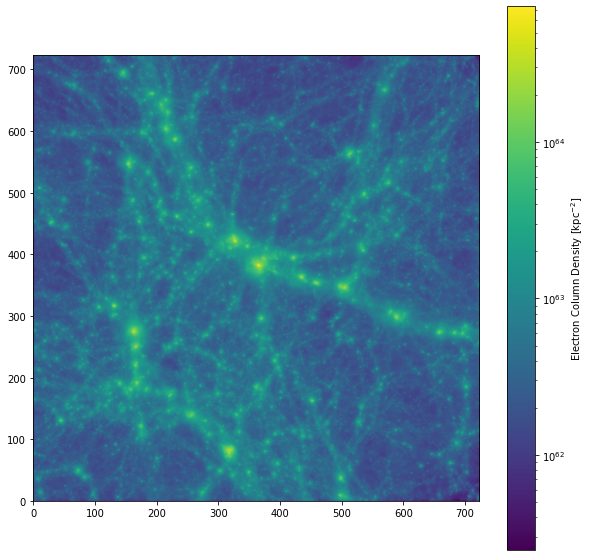

In [29]:
plt.figure(figsize=[10,10])
plt.imshow(nemap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(label=r'Electron Column Density [kpc$^{-2}$]') # note: the values of electron column density are very large since it's a projected quantity and over kpc2

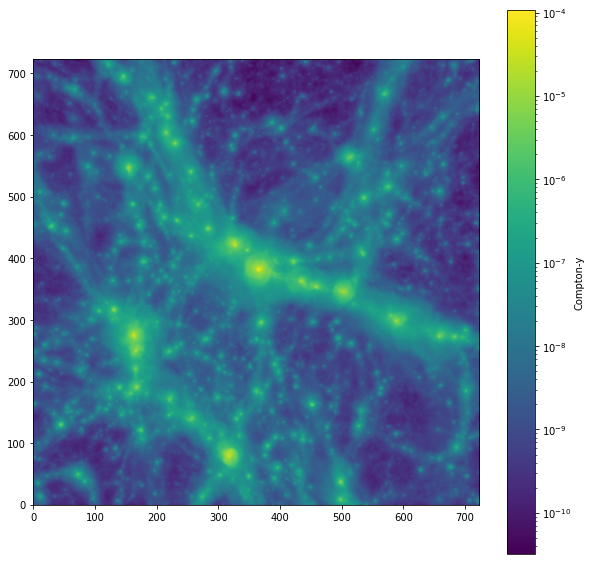

In [26]:
plt.figure(figsize=[10,10])
plt.imshow(ymap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(label='Compton-y')

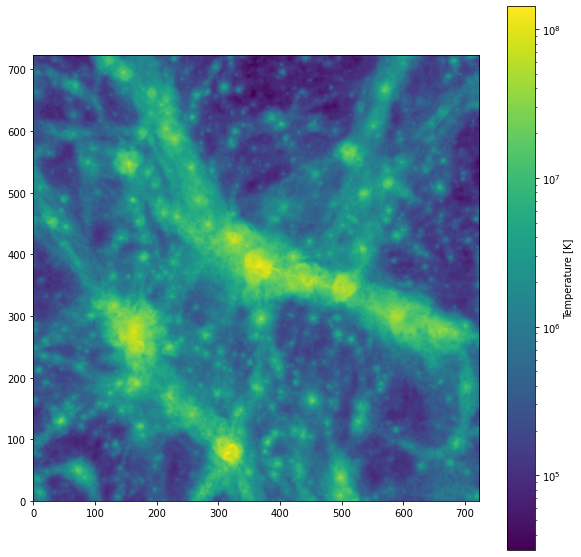

In [27]:
plt.figure(figsize=[10,10])
plt.imshow(Tmap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar(label="Temperature [K]")